# California Housing Dataset

This notebook explores the California Housing dataset using EDA, preprocessing, model training, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Display the shape of the dataset and the head
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis (EDA)

Let's explore the dataset: check for missing values, summary statistics, and visualize distributions.

In [3]:
# Check for missing values and display summary statistics
print(df.isnull().sum())
df.describe()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


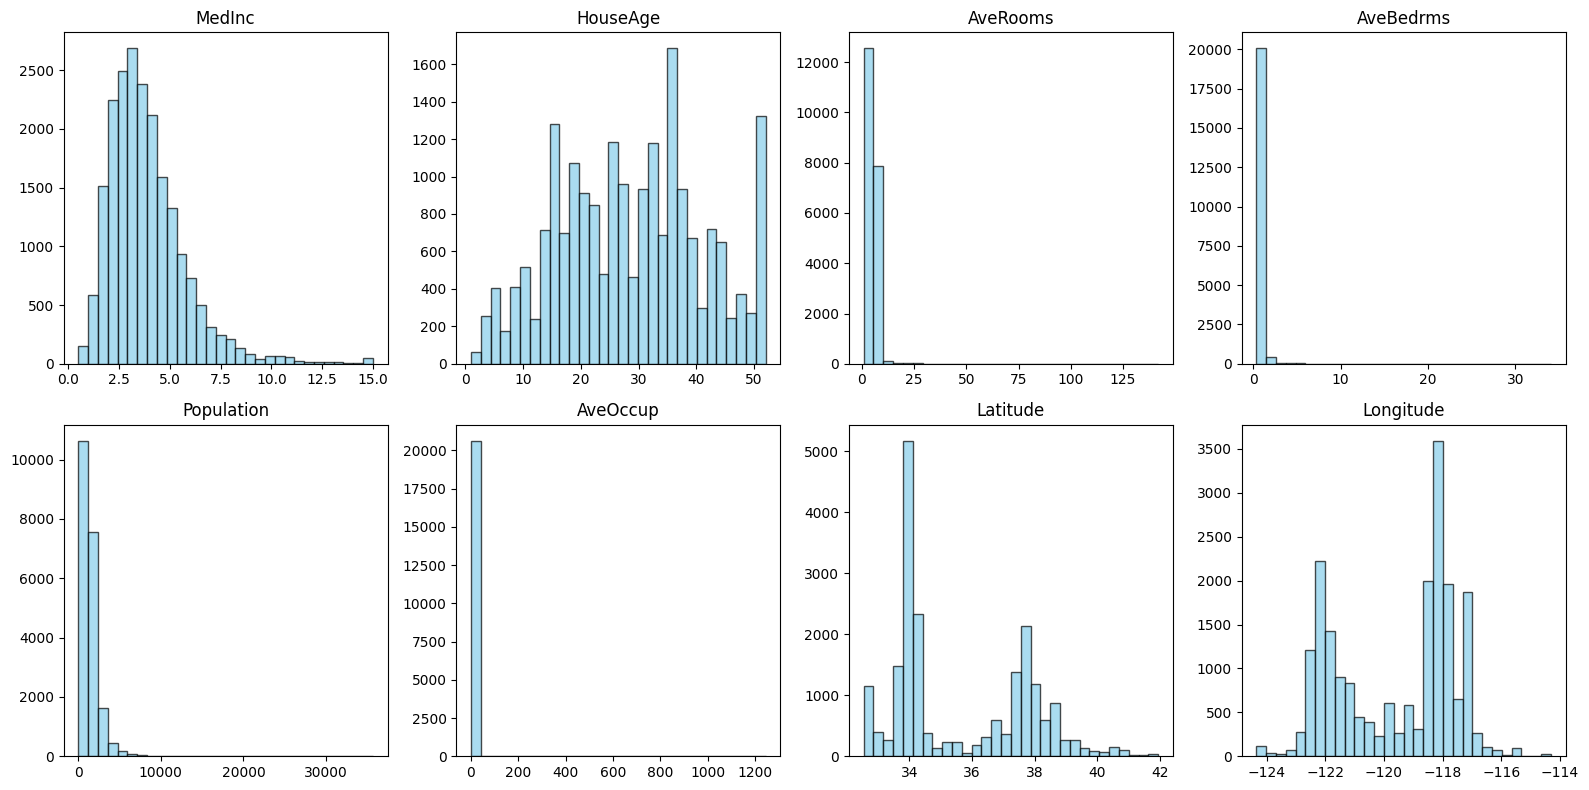

In [4]:
# Visualize feature distributions
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(df.columns[:-1]):
    axs[i // 4, i % 4].hist(df[col], bins=30, color="skyblue", edgecolor="black", alpha=0.7)
    axs[i // 4, i % 4].set_title(col)
plt.tight_layout()
plt.show()

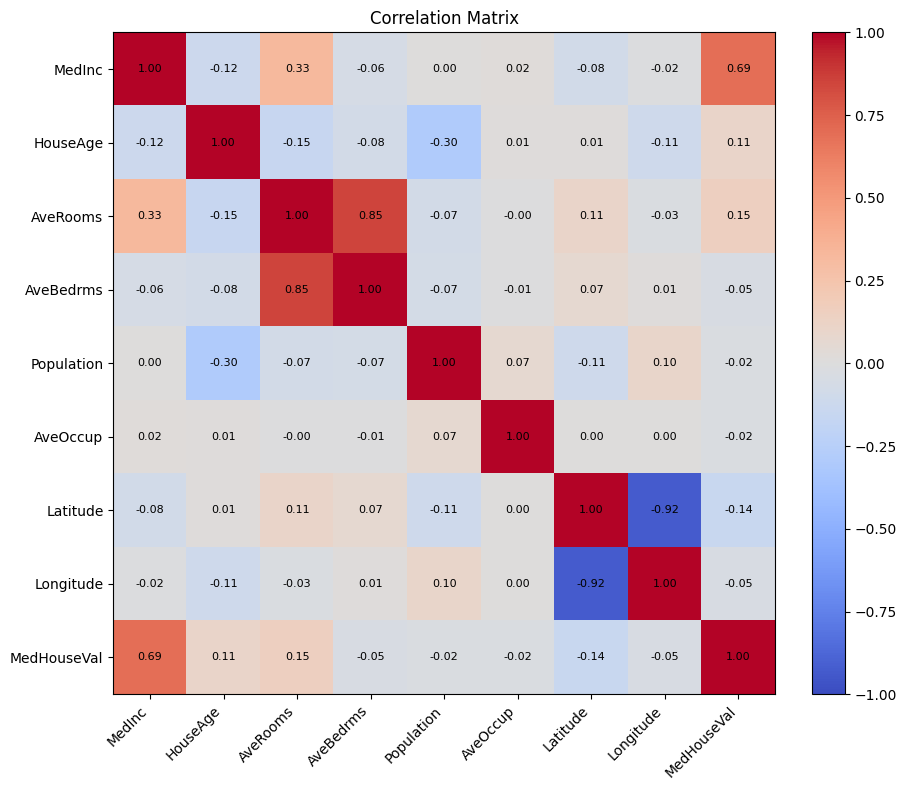

In [5]:
# Correlation heatmap
corr = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Data Preprocessing

Split the data into train and test sets, and scale the features.

In [6]:
# Split data
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

Train Linear Regression, Ridge Regression, and Random Forest models.

In [7]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [8]:
# Ridge Regression
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

In [9]:
# Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)  # use all available CPU cores
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Model Evaluation

Compare the models using RMSE and R² metrics.

In [10]:
# Evaluation function
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - RMSE: {rmse:.3f}, R²: {r2:.3f}")
    return rmse, r2


results = {}
results["Linear Regression"] = evaluate(y_test, y_pred_lr, "Linear Regression")
results["Ridge Regression"] = evaluate(y_test, y_pred_ridge, "Ridge Regression")
results["Random Forest"] = evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression - RMSE: 0.746, R²: 0.576
Ridge Regression - RMSE: 0.746, R²: 0.576
Random Forest - RMSE: 0.505, R²: 0.805


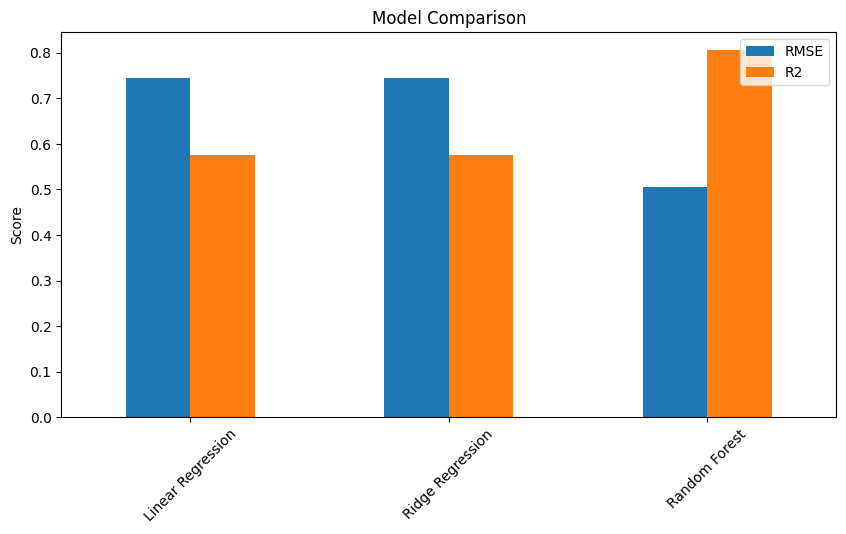

In [11]:
# Visualize model comparison
metrics = pd.DataFrame(results, index=["RMSE", "R2"]).T
metrics.plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()